# Customer Churn Prediction

**Goal:**
Predict which customers will leave (churn) a subscription service

**BUSINESS PROBLEM:**
A subscription service (e.g., telecom, streaming) wants to predict
which customers will cancel (churn) in the next month to target
them with retention offers.

**SUCCESS METRICS:**
- Recall > 0.75 (catch 75% of churners)
- Precision > 0.60 (avoid too many false alarms)
- F1 Score > 0.67 (balance both)

**CONSTRAINTS:**
- Imbalanced data (only ~20% churn)
- Need to explain predictions to retention team
- Budget: Can only target top 30% of customers

### Importing Dependencies

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
precision_recall_curve, f1_score)

import joblib

#### Data Understanding and EDA

In [2]:
df = pd.read_csv('customer_churn.csv')
df.sample(5)

,customer_id,tenure_months,monthly_charges,contract_type,payment_method,num_support_calls,service_usage_gb,num_services,paperless_billing,senior_citizen,has_partner,has_dependents,churn
113,114,52,109.657466,one year,auto,3,57.328809,3,0,0,0,0,0
202,203,23,104.612421,two year,manual,1,52.866636,1,1,0,0,0,0
4105,4106,53,48.793409,one year,auto,3,41.612451,5,1,1,0,0,0
4123,4124,69,98.135622,month-to-month,auto,1,41.527959,4,1,1,0,1,1
4793,4794,65,115.991669,one year,auto,2,37.148738,1,0,0,0,0,0


In [3]:
print(df.shape)
print(df.columns)

(5000, 13)
Index(['customer_id', 'tenure_months', 'monthly_charges', 'contract_type',
       'payment_method', 'num_support_calls', 'service_usage_gb',
       'num_services', 'paperless_billing', 'senior_citizen', 'has_partner',
       'has_dependents', 'churn'],
      dtype='object')


In [4]:
print(f'Label Distribution:\n{df.churn.value_counts()}')
print('*' * 40)
print(f'Churn Rate:\n{df["churn"].mean():.2f}')

Label Distribution:
churn
0    3221
1    1779
Name: count, dtype: int64
****************************************
Churn Rate:
0.36


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   int64  
 1   tenure_months      5000 non-null   int64  
 2   monthly_charges    5000 non-null   float64
 3   contract_type      5000 non-null   object 
 4   payment_method     5000 non-null   object 
 5   num_support_calls  5000 non-null   int64  
 6   service_usage_gb   5000 non-null   float64
 7   num_services       5000 non-null   int64  
 8   paperless_billing  5000 non-null   int64  
 9   senior_citizen     5000 non-null   int64  
 10  has_partner        5000 non-null   int64  
 11  has_dependents     5000 non-null   int64  
 12  churn              5000 non-null   int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 507.9+ KB


In [6]:
df.describe()

,customer_id,tenure_months,monthly_charges,num_support_calls,service_usage_gb,num_services,paperless_billing,senior_citizen,has_partner,has_dependents,churn
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,36.299000,69.315743,1.99500,50.008714,2.99300,0.614200,0.149000,0.501000,0.303400,0.355800
std,1443.520003,20.646851,28.611204,1.40163,15.767753,1.40675,0.486832,0.356124,0.500049,0.459772,0.478803
min,1.000000,1.000000,20.005283,0.00000,9.170256,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.750000,19.000000,44.819872,1.00000,38.644713,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2500.500000,36.000000,68.639833,2.00000,48.333235,3.00000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,3750.250000,54.000000,93.818694,3.00000,59.304233,4.00000,1.000000,0.000000,1.000000,1.000000,1.000000
max,5000.000000,72.000000,119.946068,9.00000,150.693891,5.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.groupby('contract_type')['churn'].mean().sort_values(ascending = False)

contract_type
month-to-month    0.503953
one year          0.214779
two year          0.188845
Name: churn, dtype: float64

In [8]:
tenure = pd.cut(df['tenure_months'], bins = [0, 12, 24, 36, 100], labels = ['0-12', '12-24', 
                                                                                '24-36', '36+'])
df.groupby(tenure, observed = False)['churn'].mean()

tenure_months
0-12     0.497549
12-24    0.321059
24-36    0.345196
36+      0.324838
Name: churn, dtype: float64

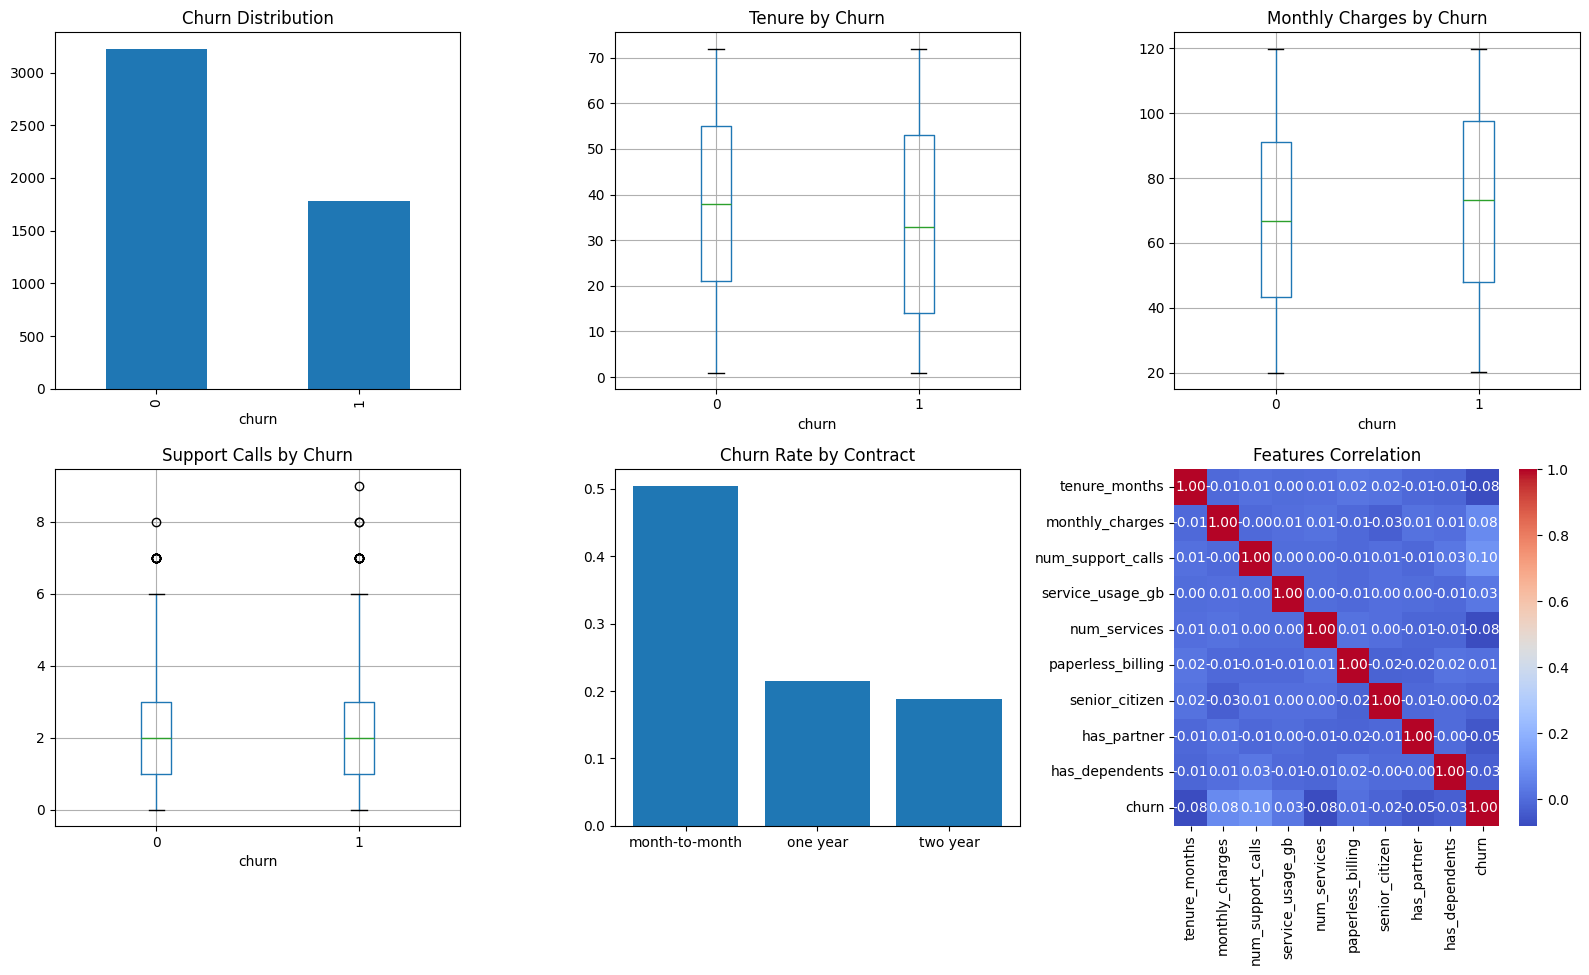

In [9]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
df['churn'].value_counts().plot(kind = 'bar')
plt.title('Churn Distribution')

plt.subplot(2, 3, 2)
df.boxplot(column = 'tenure_months', by = 'churn', ax = plt.gca())
plt.title('Tenure by Churn')

plt.subplot(2, 3, 3)
df.boxplot(column = 'monthly_charges', by = 'churn', ax = plt.gca())
plt.title('Monthly Charges by Churn')

plt.subplot(2, 3, 4)
df.boxplot(column = 'num_support_calls', by = 'churn', ax = plt.gca())
plt.title('Support Calls by Churn')

plt.subplot(2, 3, 5)
churn_by_contract = df.groupby('contract_type')['churn'].mean()
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.title('Churn Rate by Contract')

plt.subplot(2, 3, 6)
num_cols = df.select_dtypes(include = [np.number]).drop('customer_id', axis = 1).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', ax = plt.gca(), cbar = True)
plt.title('Features Correlation')

plt.suptitle("")
plt.tight_layout()
plt.show()

#### Data Preprocessing

In [11]:
df.columns

Index(['customer_id', 'tenure_months', 'monthly_charges', 'contract_type',
       'payment_method', 'num_support_calls', 'service_usage_gb',
       'num_services', 'paperless_billing', 'senior_citizen', 'has_partner',
       'has_dependents', 'churn'],
      dtype='object')

In [17]:
X = df.drop(['customer_id', 'churn'], axis = 1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

num_features = ['tenure_months', 'monthly_charges', 'num_support_calls', 'service_usage_gb',
       'num_services', 'paperless_billing', 'senior_citizen', 'has_partner', 'has_dependents']
cat_features = ['contract_type', 'payment_method']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop = 'first'), cat_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'X_train_processed Shape: {X_train_processed.shape}')
print(f'X_test_processed Shape: {X_test_processed.shape}')

X_train_processed Shape: (4000, 12)
X_test_processed Shape: (1000, 12)


#### Handling Imbalanced Data

In [25]:
model_weights = RandomForestClassifier(n_estimators = 200, class_weight = 'balanced', random_state = 42)

smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

model_smote = RandomForestClassifier(n_estimators = 200, random_state = 42)

# Baseline without handling
model_baseline = RandomForestClassifier(n_estimators = 200, random_state = 42)
model_baseline.fit(X_train_processed, y_train)
y_pred_baseline = model_baseline.predict(X_test_processed)
print(classification_report(y_test, y_pred_baseline))

# With class weights
model_weights.fit(X_train_processed, y_train)
y_pred_weights = model_weights.predict(X_test_processed)
print(classification_report(y_test, y_pred_weights))

# Using SMOTE
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_processed)
print(classification_report(y_test, y_pred_smote))

best_model = model_weights

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       644
           1       0.51      0.34      0.41       356

    accuracy                           0.65      1000
   macro avg       0.60      0.58      0.58      1000
weighted avg       0.63      0.65      0.63      1000

              precision    recall  f1-score   support

           0       0.70      0.84      0.76       644
           1       0.55      0.35      0.43       356

    accuracy                           0.67      1000
   macro avg       0.63      0.60      0.60      1000
weighted avg       0.65      0.67      0.65      1000

              precision    recall  f1-score   support

           0       0.71      0.74      0.73       644
           1       0.49      0.45      0.47       356

    accuracy                           0.64      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.63      0.64      0.64      1000



In [30]:
y_pred_proba = best_model.predict_proba(X_test_processed)[:, 1]
# print(y_pred_proba)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision + recall) / (precision + recall + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal Threshold: {optimal_threshold:.3f}')
print(f'F1 at optimal threshold: {f1_scores[optimal_idx]:.4f}')

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print('\nPerformance with optimal threshold')
print(classification_report(y_test, y_pred_optimal))

Optimal Threshold: 0.120
F1 at optimal threshold: 2.0000

Performance with optimal threshold
              precision    recall  f1-score   support

           0       0.96      0.17      0.29       644
           1       0.40      0.99      0.56       356

    accuracy                           0.46      1000
   macro avg       0.68      0.58      0.43      1000
weighted avg       0.76      0.46      0.38      1000



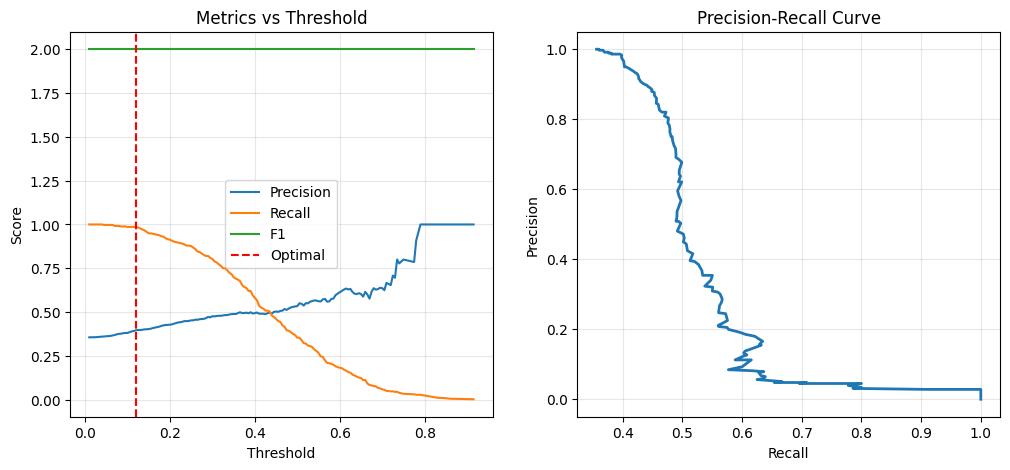

In [50]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[: -1], label = 'Precision')
plt.plot(thresholds, recall[: -1], label = 'Recall')
plt.plot(thresholds, f1_scores[: -1], label = 'F1')
plt.axvline(optimal_threshold, color = 'r', linestyle = '--', label = 'Optimal')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha = 0.3)


plt.subplot(1, 2, 2)
plt.plot(precision, recall, linewidth = 2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha = 0.3)

plt.tight_layout
plt.show()

#### Model Interpretation

In [41]:
feature_names = (num_features + list(preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_features)))
# print(feature_names)

importance_df = pd.DataFrame({'feature' : feature_names, 
                              'importance' : best_model.feature_importances_}).sort_values(
                              'importance', ascending = False)
print(importance_df.head(10))

                   feature  importance
1          monthly_charges    0.207116
3         service_usage_gb    0.201029
0            tenure_months    0.188462
2        num_support_calls    0.091905
4             num_services    0.073705
9   contract_type_one year    0.059123
10  contract_type_two year    0.049406
5        paperless_billing    0.029089
7              has_partner    0.028323
8           has_dependents    0.026493


In [47]:
df_test = X_test.copy()
df_test['churn_probability'] = y_pred_proba
df_test['actual_churn'] = y_test
df_test['risk_segment'] = pd.cut(df_test['churn_probability'], bins = [0, 0.3, 0.7, 1.0], 
                                labels = ['Low Risk', 'Medium Risk', 'High Risk'])

print(f'Customer by Risk Segment:\n{df_test['risk_segment'].value_counts()}')
print(f'Actual Churn Rate by Predicted Risk:\n{df_test.groupby('risk_segment', observed = False)[
    'actual_churn'].mean()}')

high_risk = df_test[df_test['risk_segment'] == 'High Risk']
print('Retention:')
print(f'Target {len(high_risk)} high-risk customers')
print(f'Expected to catch {high_risk['actual_churn'].sum()} churners')
print(f'Precision: {high_risk['actual_churn'].mean():.2%}')

Customer by Risk Segment:
risk_segment
Medium Risk    559
Low Risk       409
High Risk       32
Name: count, dtype: int64
Actual Churn Rate by Predicted Risk:
risk_segment
Low Risk       0.183374
Medium Risk    0.466905
High Risk      0.625000
Name: actual_churn, dtype: float64
Retention:
Target 32 high-risk customers
Expected to catch 20 churners
Precision: 62.50%


#### Saving Model

In [48]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])
full_pipeline.fit(X_train, y_train)

model_package = {
    'pipeline' : full_pipeline,
    'threshold' : optimal_threshold,
    'feature_importance' : importance_df.to_dict(),
    'metrics' : {
        'f1' : f1_scores[optimal_idx],
        'precision' : precision[optimal_idx],
        'recall' : recall[optimal_idx],
        'roc_auc' : roc_auc_score(y_test, y_pred_proba)
        },
    'version' : '1.0.0',
    'date' : pd.Timestamp.now().isoformat()
}

joblib.dump(model_package, 'churn_model_v1.pkl', compress = 3)
print('Model Saved')

Model Saved
